# Single-contact spike detection (Real Data, CH19)
** The Goal** is to detect the firing of one known nerve fibre in a real rat saphenous nerve recording. This notebook only experiments on one channel, which is channel19. 
**The ground truth**: the lab marked 1,623 spikes for this unit. Here, the detections were tested against those markes. 
**The code difficulty encountered in this notebook in five ways:** the electrode picks up many fibres at once, so on a single channel  its diffecult to tell which fibre a given spike came from.

In [1]:
#imports 
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import h5py

from src.evaluate import detect_spikes, score_detections
from scipy.signal import correlate, find_peaks
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, recall_score, f1_score
import torch
import torch.nn as nn

path = r"C:\spike-denoising-synthetic\data\real"
sample_rate = 30000

print("setup ok")

setup ok


## 1. Setup and data 
Load the recording and the ground truth. The data is one file per channel (float64, 30 kHz), already filtered (300-6000 Hz), and artefacts were blanked by the lab. 
ground truth is a MATLAB v7.3 file, and read by h5py

Here I worked on a 300 second window starting at stimulus 900, which is a stable stretch of the recording. All the times share one clock, and this is was verified against time_series_2.bin (starts at 1.03s, 30 kHz spacing)

In [2]:
#Load the ground truth
gt = h5py.File(path + r"\grouped_unit_1.mat", "r")
print("top-level fields:", [k for k in gt.keys() if not k.startswith("#")])
zc_ch19 = gt["CH19"]["aligned_zc_locs"][:].flatten()

print("Spikes on CH19:", len(zc_ch19))
print("time range (s): %.1f to %.1f" % (zc_ch19.min(), zc_ch19.max()))

top-level fields: ['CH10', 'CH14', 'CH19', 'CH25', 'CH3', 'CH30', 'CH9', 'filename', 'group_number', 'primary_channel']
Spikes on CH19: 1623
time range (s): 1754.5 to 8265.2


the analysis window begins at index 900 of TTLs_2.bin (t = 3602.67 s); the phase table's TTL numbering implies a start ~70 s earlier, so the file's own indexing was used as it shares a time base with the recording and ground truth.

In [3]:
# Define the window
ttls = np.fromfile(path + r"\TTLs_2.bin", dtype='<f8')

print("number of TTLs:", len(ttls))
print("spacing (s):", np.diff(ttls[:5]))

# MATLAB counts from 1, PYTHON from 0
print("ttls[792]:", ttls[792])  
print("ttls[900]:", ttls[900]) 

t_start = ttls[900]      
t_end   = t_start + 300

print("window: %.2f to %.2f s" % (t_start, t_end))
print("stimuli in window:", ((ttls >= t_start) & (ttls <= t_end)).sum())

number of TTLs: 2310
spacing (s): [4.0007     4.0007     4.00073333 4.0007    ]
ttls[792]: 3170.5945666666667
ttls[900]: 3602.6708
window: 3602.67 to 3902.67 s
stimuli in window: 75


In [4]:
ch19_file = path + r"\100_RhythmData_CH19_2_filtered_blanked.bin"
start_idx = int(t_start * sample_rate)

In [5]:
# Load CH19 for that window
n_samples = int(300 * sample_rate)
ch19 = np.fromfile(ch19_file, dtype='<f8', count=n_samples, offset=start_idx * 8)

t_end = t_start + len(ch19) / sample_rate     
noise_mad = np.median(np.abs(ch19)) / 0.6745
gt_in_win = zc_ch19[(zc_ch19 >= t_start) & (zc_ch19 <= t_end)]

print("samples loaded:", len(ch19))
print("seconds: %.1f" % (len(ch19) / sample_rate))
print("noise (MAD): %.2f" % noise_mad)
print("ground-truth spikes in window:", len(gt_in_win))

samples loaded: 9000000
seconds: 300.0
noise (MAD): 4.94
ground-truth spikes in window: 71


## The loaded window:
9,000,000 samples (300 s), noise floor MAD 4.92, 71 ground truth spikes inside the window. These are what every method below is scored against

## 2 characterise the spikes
How deep are the real spikes relative to the noise?

In [6]:
# Characterise the spikes: for each ground truth spike time in the window, convert to a sample index

half = 45  #1.5 ms at 30 kHz

depths = []
for st in gt_in_win:
    i = int((st - t_start) * sample_rate)  # index within the loaded window 
    seg = ch19[i - half : i + half]
    if len(seg) == 2 * half:
        depths.append(seg.min())
depths = np.array(depths)
ratios = depths / noise_mad

print("spikes measured:", len(depths))
print("median depth: %.2f (%.2f \ noise)" % (np.median(depths), np.median(ratios)))
print("5th percentile:  %.2f x noise" % np.percentile(ratios, 5))
print("95th percentile: %.2f x noise" % np.percentile(ratios, 95))

spikes measured: 71
median depth: -11.32 (-2.29 \ noise)
5th percentile:  -3.51 x noise
95th percentile: -1.45 x noise


### Results:
The unit's spike spans 1.2x to 5.2x the noise floor. Some stand clear of the noise; many sit almost inside it. This range is the main reason for the follwing problems incounters; a threshold deep enough to reject noise also rejects the shallow spikes.  

## 3. Detection by depth
a simple detector to flag anything tahat dips below a threshold set at k x noise. Sweep k and score against the ground truth

In [7]:
# threshold detection 
print(f"{'k':>5s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for k in [1.5, 2, 2.5, 3, 4]:
    det = detect_spikes(ch19, sample_rate, k=k) + t_start
    precision, recall, f1 = score_detections(det, gt_in_win, tolerance=0.002) 
    print(f"{k:5.1f} {len(det):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

    k  detected  precision   recall      F1
  1.5     76540     0.0008    0.887   0.002
  2.0     57028     0.0009    0.718   0.002
  2.5     33923     0.0009    0.451   0.002
  3.0     17456     0.0010    0.254   0.002
  4.0      5219     0.0008    0.056   0.002


### Results for detection by depth:
At every k, the precision stays between 0.0008 and 0.0010, which is flat, and no threshold works
At k=1.5, the detector catches 89% of spikes (recall 0.887), but fires 76,540 times to find 71 spikes; about 1000 detections per real spike. When k is raised, the noise is rejected, but also shallow spikes get rejected, so recall falls from 0.887 to 0.056, while precision stays flat and F1 stays at 0.002 throughout. 

These results are the consequence of the depth range in step 2, where spikes span 1.2x-5.2x noise, straddling the noise floor; any threshold shallow enough to catch the shallow spikes also catches noise; any threshold deep enough to reject noise also rejects the shallow spikes. So, depth can not separate a real spike from a noise bump of the same depth.

This motivated the next step to try shape instead. 

## 4. Building a spike template
To detect by shape, the unit's average waveform needs to be built:

- Use spikes from inside the window only; a fibre's waveform can drift over a long recording, so a template from the whole recording may not match this stretch. 

- Realign each spike before averaging: the ground truth marks sit at the zero-crossing, not the trough, and the gap varies per spike. Averaging on the raw marks would smear the spikes and cancel them towards zero, so for each spike a 3ms window is taken, search 1ms for the actual trough and align on that. 

In [8]:
# Build the template
half   = 45      # 1.5 ms template width
search = 30      # 1 ms how far to look for the true trough

segs = []
for st in gt_in_win:
    i = int((st - t_start) * sample_rate)
    lo, hi = i - half - search, i + half + search
    if lo < 0 or hi > len(ch19):
        continue
    wide   = ch19[lo:hi]
    centre = half + search
    trough = np.argmin(wide[centre - search : centre + search]) + (centre - search)
    seg    = wide[trough - half : trough + half]
    if len(seg) == 2 * half:
        segs.append(seg)

segs = np.array(segs)
template = segs.mean(axis=0)

print("spikes averaged:", len(segs))
print("template trough: %.2f" % template.min())
print("trough / noise:  %.2f" % (template.min() / noise_mad))

spikes averaged: 71
template trough: -11.31
trough / noise:  -2.29


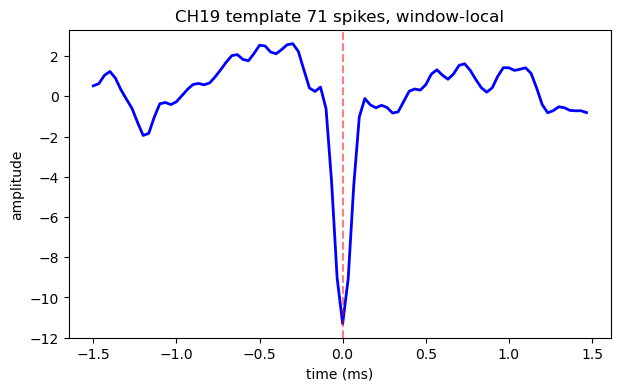

In [9]:
t_ms = (np.arange(2 * half) - half) / sample_rate * 1000
plt.figure(figsize=(7, 4))
plt.plot(t_ms, template, 'b', linewidth=2)
plt.axvline(0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('time (ms)'); plt.ylabel('amplitude')
plt.title('CH19 template %d spikes, window-local' % len(segs))
plt.show()

### Results:
Averaged over 71 spikes, the template has a clean, sharp trough of -11.31, about 2.3x the noise floor. This is the template I will be matching against.
**Next step** is sliding this template along the recording to detect spikes by their shape.

## 5. Detection by shape (template matching)
In this step, the previous template will be slid along the whole recording and score the match at every point using normalised cross-correlation. Normalising makes the score scale-invariant; it measures shape, not the size so a shallow spike with the right shape still scores high. Scores run from -1 (opposite shape) through 0  (no match) to +1 (identical shape). Then find the peaks in the match score. 

The blanked flat regions where stimulus artefacts were set to a constant have zero local variance, which makes the normalisation divide by zero. So, the local variance is computed in a numerically stable way and the score is set to zero in those regions. 

In [10]:
# template matching
from scipy.ndimage import uniform_filter1d

def template_match(signal, template):
    t = template - template.mean()
    t = t / np.linalg.norm(t)
    n = len(t)
    num = correlate(signal, t, mode='same')
    m   = uniform_filter1d(signal,    n, mode='nearest')
    m2  = uniform_filter1d(signal**2, n, mode='nearest')
    var = np.maximum(m2 - m**2, 0)
    denom = np.sqrt(var * n)
    return np.divide(num, denom, out=np.zeros_like(num), where=denom > 1e-6)

scores = template_match(ch19, template)
print("score range: %.3f to %.3f" % (scores.min(), scores.max()))
print("zeroed samples:", (scores == 0).sum())

score range: -0.824 to 0.865
zeroed samples: 480


In [11]:
print(f"{'thresh':>7s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    peaks, _ = find_peaks(scores, height=th, distance=90)
    det = peaks / sample_rate + t_start
    precision, recall, f1 = score_detections(det, gt_in_win, tolerance=0.002)
    print(f"{th:7.1f} {len(peaks):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

 thresh  detected  precision   recall      F1
    0.3     64183     0.0009    0.775   0.002
    0.4     49626     0.0009    0.662   0.002
    0.5     26248     0.0012    0.451   0.002
    0.6      8709     0.0014    0.169   0.003
    0.7      1664     0.0018    0.042   0.003


### Results for detected by shape
The precision is between 0.0009 and 0.0019 across all thresholds, which is no better than depth detection. As the threshold is raised, the detections dropped from 64,183 at 0.3 to 1,664 at 0.7, but precision never rises above 0.0018 and recall drops from 0.775 to 0.042. And F1 stays at 0.002-0.003 throughout. 

This concludes that shape also does not separate the target unit from everything else. 
**Next step** is to test whether real spikes even score higher than the other detections?  

## 6. This step tests why shape fails
Template matching for shape gave no better precision than depth. So the question is: do real spikes score higher than everything else the detector flags? If yes, that means there's a threshold that can separate them. If they overlap, shape detection can not work at any threshold. 
So, in this step, the match scores at the known spike times will be compared against the scores of all detected peks. 

In [12]:
gt_scores = []
for st in gt_in_win:
    i = int((st - t_start) * sample_rate)
    if 90 < i < len(scores) - 90:
        gt_scores.append(scores[i-90:i+90].max())
gt_scores = np.array(gt_scores)

peaks, _ = find_peaks(scores, height=0.3, distance=90)
print("true spikes- median score: %.3f, 5th: %.3f, 95th: %.3f"
      % (np.median(gt_scores), np.percentile(gt_scores,5), np.percentile(gt_scores,95)))
print("all peaks- median score: %.3f, 95th: %.3f"
      % (np.median(scores[peaks]), np.percentile(scores[peaks],95)))

true spikes- median score: 0.519, 5th: 0.408, 95th: 0.707
all peaks- median score: 0.475, 95th: 0.666


### Results 
The results show that the two distributions overlap. True spikes score a median of 0.519 (5th–95th percentile: 0.408–0.707); all detected peaks score a median of 0.475 (95th: 0.666). The real spikes are a bit higher and their range on top of the general population; the true spike 5th percentile (0.408) is below the all-peak median. 
No threshold separating them, because the other high-scoring peaks are also real spikes from other fibres with near-identical shapes to the true spike (ground truth). Because the background detection scored almost as high of a median as the real spikes, the background signals must be spike-shaped (other neurons/fibers). 
**In conclusion**, in single-channel analysis, shape can not say which fibre a spike came from, because different fibres produce the same or similar shape. 

## 7. Ground truth spikes latency measurement
For each ground truth spike, find the preceding stimulus and compute the latency between them. if the unit is time-locked,  these latencies will cluster. 

median latency: 100.6 ms
5th–95th percentile: 99.9 – 102.4 ms


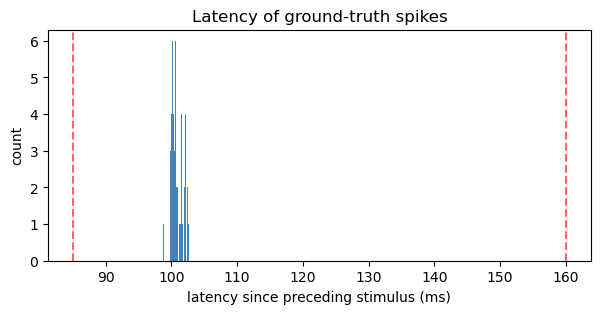

In [13]:
def spike_latencies(spike_times, ttls):
    idx = np.searchsorted(ttls, spike_times) - 1
    ok = idx >= 0
    lat = spike_times[ok] - ttls[idx[ok]]
    return lat

lat = spike_latencies(gt_in_win, ttls) * 1000   # ms

print("median latency: %.1f ms" % np.median(lat))
print("5th–95th percentile: %.1f – %.1f ms" % (np.percentile(lat, 5), np.percentile(lat, 95)))

plt.figure(figsize=(7,3))
plt.hist(lat, bins=40, color='steelblue')
plt.axvline(85, color='r', linestyle='--', alpha=0.6)
plt.axvline(160, color='r', linestyle='--', alpha=0.6)
plt.xlabel('latency since preceding stimulus (ms)')
plt.ylabel('count')
plt.title('Latency of ground-truth spikes')
plt.show()

In [14]:
print("n spikes:", len(gt_in_win))
print("first 5 latencies (ms):", np.round(spike_latencies(gt_in_win, ttls)[:5]*1000, 1))
print("min, max latency (ms):", 
      np.round(spike_latencies(gt_in_win, ttls).min()*1000,1),
      np.round(spike_latencies(gt_in_win, ttls).max()*1000,1))

n spikes: 71
first 5 latencies (ms): [102.4 102.6 102.4 102.2 102.2]
min, max latency (ms): 98.8 102.6


### Results
The ground truth spikes cluster tightly with a median latency of 100.6 ms (time-locked), and all 71 spikes fall between 98.8 and 102.6 ms (a ~4 ms spread). The unit fires at almost the same latency after every stimulus. 

## 8. Adding timing (the latency constraint)
Both depth and shape failed because they can not tell the target unit from other fibres. This step will check when a spike occurs. 
The unit fires at a consistent latency after each stimulus (71 spikes:98.8 and 102.6 ms). So, the only detections kept are those that fall post stimulus latency window, following Troglio et al. (2025). For each detection, 'np.searchsorted' finds the preceding stimulus and then the latency since the stimulus is checked. 
Two windows are tested: a wide 85-160 ms (which is a safe margin and the standard practice) and a tight 95-107 ms which matches the unit's actual measured cluster. 

In [15]:
# The latency constraint following Troglio et al. (2026)
def in_latency_window(times, ttls, lat_min=0.085, lat_max=0.160):
    idx = np.searchsorted(ttls, times) - 1
    has_ttl = idx >= 0
    latency = np.full(len(times), np.inf)
    latency[has_ttl] = times[has_ttl] - ttls[idx[has_ttl]]
    return (latency >= lat_min) & (latency <= lat_max)

In [16]:
for th in [0.3, 0.5, 0.7]:
    peaks, _ = find_peaks(scores, height=th, distance=90)
    det = peaks / sample_rate + t_start
    det_c = det[in_latency_window(det, ttls)]
    precision, recall, f1 = score_detections(det_c, gt_in_win, tolerance=0.002)
    print(f"{th:7.1f} {len(det):8d} {len(det_c):6d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

    0.3    64183   1193     0.0461    0.775   0.087
    0.5    26248    495     0.0646    0.451   0.113
    0.7     1664     30     0.1000    0.042   0.059


In [17]:
# Sweep
print(f"{'thresh':>7s} {'raw':>8s} {'kept':>6s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    peaks, _ = find_peaks(scores, height=th, distance=90)
    det = peaks / sample_rate + t_start
    det_c = det[in_latency_window(det, ttls)]
    precision, recall, f1 = score_detections(det_c, gt_in_win, tolerance=0.002)
    print(f"{th:7.1f} {len(det):8d} {len(det_c):6d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")


 thresh      raw   kept  precision   recall      F1
    0.3    64183   1193     0.0461    0.775   0.087
    0.4    49626    948     0.0496    0.662   0.092
    0.5    26248    495     0.0646    0.451   0.113
    0.6     8709    172     0.0698    0.169   0.099
    0.7     1664     30     0.1000    0.042   0.059


In [18]:
# tighter latency window (95–107 ms) matching the observed cluster
print("tight window 95–107 ms")
print(f"{'thresh':>7s} {'raw':>8s} {'kept':>6s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    peaks, _ = find_peaks(scores, height=th, distance=90)
    det = peaks / sample_rate + t_start
    det_c = det[in_latency_window(det, ttls, lat_min=0.095, lat_max=0.107)]
    precision, recall, f1 = score_detections(det_c, gt_in_win, tolerance=0.002)
    print(f"{th:7.1f} {len(det):8d} {len(det_c):6d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

tight window 95–107 ms
 thresh      raw   kept  precision   recall      F1
    0.3    64183    181     0.3039    0.775   0.437
    0.4    49626    145     0.3241    0.662   0.435
    0.5    26248     88     0.3636    0.451   0.403
    0.6     8709     32     0.3750    0.169   0.233
    0.7     1664      6     0.5000    0.042   0.078


## Results for latency constraint

The wide window 85-160 ms raises precision from 0.0018 (shape alone)  -> to 0.045, but 9 of every 10 detection are still wrong. At match threshold 0.3: 64,183 detections cut to 1193, recall 0.775 and F1 0.087.
Timing does help, but this window is far wider than it lets other fibres fire near through. 

Matching the unit's measured 98.8 - 102.6 ms cluster and narrowing the latency filter to 95-107 ms has raised the precision sharply while also keeping the recall unchanged. At match threshold 0.3: the precision went from 0.046 -> 0.304 (6.6x), recall held at 0.775, F1 went from 0.087 -> 0.437, and detected spikes were cut from 1,193 to 181. The gain was held across the sweep. 
Most of the false positives the wide window let through were other fibres firing outside the target's 98.8–102.6 ms band; the tight window rejects them while keeping every true spike. This is the strongest result so far from timing alone.

However, this window is specific to this stable stimulation epoch. Across the whole recording, the unit's latency spreads to ~94–152 ms, so 95–107 ms would not generalise. The window was also derived from the same spikes it is scored against; a window derived from held-out stimuli would be cleaner.

## 9. Wavelet denoising on Ch19 single contact 
Wavelet denoising db4, level4, soft threshold. 

In [19]:
from src.denoisers import denoise_wavelet_channel

ch19_wav = denoise_wavelet_channel(ch19)
print("original MAD:", np.median(np.abs(ch19)) / 0.6745)
print("denoised MAD:", np.median(np.abs(ch19_wav)) / 0.6745)

original MAD: 4.940607499725379
denoised MAD: 3.1998030435268485


In [20]:
# Detection sweep on wavelet denoising
print(f"{'k':>5s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for k in [1.5, 2, 2.5, 3, 4]:
    det = detect_spikes(ch19_wav, sample_rate, k=k) + t_start
    precision, recall, f1 = score_detections(det, gt_in_win, tolerance=0.002)
    print(f"{k:5.1f} {len(det):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

    k  detected  precision   recall      F1
  1.5     67816     0.0008    0.789   0.002
  2.0     50749     0.0009    0.676   0.002
  2.5     33688     0.0008    0.394   0.002
  3.0     21131     0.0010    0.296   0.002
  4.0      8785     0.0006    0.070   0.001


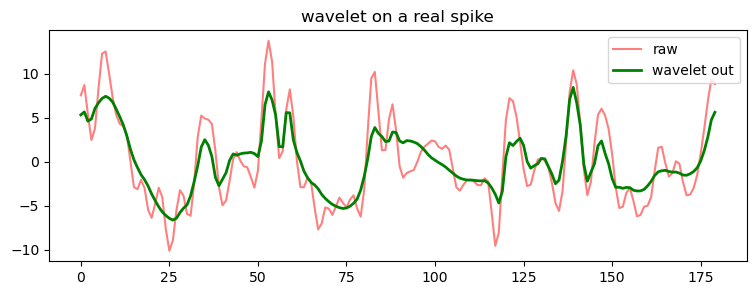

In [21]:
st = gt_in_win[5]
i = int((st - t_start) * sample_rate)
plt.figure(figsize=(9,3))
plt.plot(ch19[i-90:i+90], 'r', alpha=0.5, label='raw')
plt.plot(ch19_wav[i-90:i+90], 'g', linewidth=2, label='wavelet out')
plt.legend(); plt.title('wavelet on a real spike'); plt.show()

### Wavelet results: it made no difference 
. Precision is 0.0008 vs raw 0.0009; recall is slightly worse at low k (0.789 vs 0.887. it looks like wavelet smoothed away some shallow spikes along with the noise. 
Next is to see if Autoencoder will make a difference 

## 10. Simple dense PyTorch denoising autoencoder (ch19 single-contact)
A simple dense autoencoder uses an encoder, bottleneck, and decoder to compress a short data window into a tiny space and reconstruct it, to only keep dominant structure (spikes) and discard noise
the autoencoder will be trained on synthetic spike-plus-noise pairs, then applied to real CH19.

In [22]:
import torch 
import torch.nn as nn
print(torch.__version__)
print("CUDA:", torch.cuda.is_available())

2.11.0+cpu
CUDA: False


In [23]:
class DenseDAE(nn.Module):
    def __init__(self, window=60, hidden=15):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(window, 30),
            nn.ReLU(),
            nn.Linear(30, hidden),      
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(hidden, 30),
            nn.ReLU(),
            nn.Linear(30, window),     
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = DenseDAE(window=60, hidden=15)
print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))
        

DenseDAE(
  (encoder): Sequential(
    (0): Linear(in_features=60, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=15, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=15, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=60, bias=True)
  )
)
parameters: 4635


In [24]:
# Train on synthetic data
def make_training_pairs(n=40000, window=60, jitter=8, spike_frac=0.5, seed=0):
    rng = np.random.default_rng(seed)

    t = np.arange(window) - window // 2
    trough  = -np.exp(-(t**2) / (2 * 3.0**2))
    rebound = 0.3 * np.exp(-((t - 6)**2) / (2 * 5.0**2))
    base = trough + rebound
    base = base / np.abs(base.min())          

    clean = np.zeros((n, window))
    for i in range(n):
        if rng.random() < spike_frac:          
            shift = rng.integers(-jitter, jitter + 1)
            amp   = rng.uniform(0.5, 1.5)      
            clean[i] = np.roll(base, shift) * amp
        # else: leave it as zeros — a noise-only window

    noise_std = rng.uniform(0.1, 0.5, size=(n, 1))   # vary noise per window
    noisy = clean + rng.normal(0, 1, size=clean.shape) * noise_std

    return (torch.tensor(noisy, dtype=torch.float32),
            torch.tensor(clean, dtype=torch.float32))

In [25]:
# Trainng loop
X_train, y_train = make_training_pairs()

model = DenseDAE(window=60, hidden=15)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_mse = nn.MSELoss()
dataset = torch.utils.data.TensorDataset(X_train, y_train)
loader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=True)

for epoch in range(30):
    total = 0
    for noisy_batch, clean_batch in loader:
        optimizer.zero_grad()
        loss = loss_mse(model(noisy_batch), clean_batch)
        loss.backward()
        optimizer.step()
        total += loss.item()
    if epoch % 5 == 0 or epoch == 29:
        print(f"epoch {epoch:2d}  loss {total/len(loader):.4f}")

epoch  0  loss 0.0229
epoch  5  loss 0.0023
epoch 10  loss 0.0021
epoch 15  loss 0.0020
epoch 20  loss 0.0020
epoch 25  loss 0.0019
epoch 29  loss 0.0019


In [26]:
#Run the model on the CH19 real data
def ae_denoise_signal(signal, model, window=60, step=20):
    model.eval()
    out = np.zeros(len(signal))
    counts = np.zeros(len(signal))
    scale = np.median(np.abs(signal)) / 0.6745      

    with torch.no_grad():
        for s in range(0, len(signal) - window, step):
            w = signal[s:s+window]
            if w.std() < 1e-6:
                continue
            w_norm = w / scale                       # global scale, keeps spikes big
            recon = model(torch.tensor(w_norm, dtype=torch.float32)).numpy()
            out[s:s+window]    += recon * scale
            counts[s:s+window] += 1

    counts[counts == 0] = 1
    return out / counts
ch19_ae = ae_denoise_signal(ch19, model)

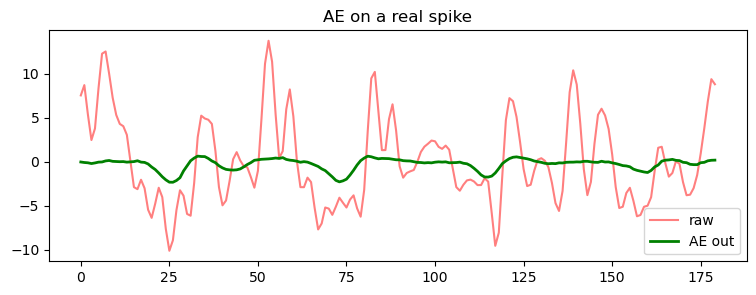

In [27]:
st = gt_in_win[5]
i = int((st - t_start) * sample_rate)
plt.figure(figsize=(9,3))
plt.plot(ch19[i-90:i+90], 'r', alpha=0.5, label='raw')
plt.plot(ch19_ae[i-90:i+90], 'g', linewidth=2, label='AE out')
plt.legend(); plt.title('AE on a real spike'); plt.show()

### Autoencoder Results (trained first on synthetic shape) 
The autoencoder reconstructs the synthetic spikes well, but seems to crush the real spikes to near flat, as seen in the plot; the green reconstruction sits flat where the raw signal has a clear tough. 
This could be because the synthetic difference of Gaussians shape does not match the real spikes, so the autoencoder doesn't recognise it. So, the next setp io to attempt to test this by training on the real spike's own shape. 

## 11. Autoencoder trained on real spikes shape

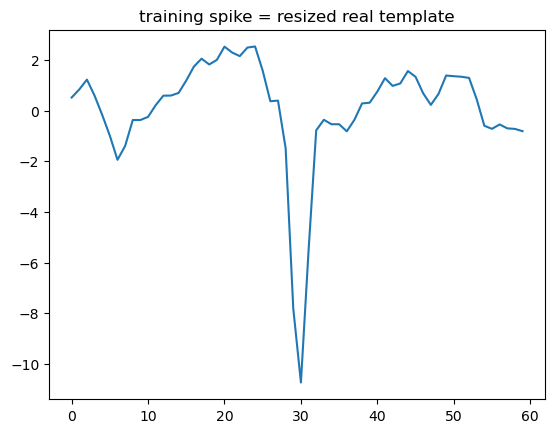

In [28]:
base = template.copy()
x_old = np.linspace(0, 1, len(base))
x_new = np.linspace(0, 1, 60)
base = np.interp(x_new, x_old, base)
plt.plot(base); plt.title('training spike = resized real template'); plt.show()

In [29]:
def make_training_pairs_real(n=40000, window=60, jitter=8, spike_frac=0.5, seed=0):
    rng = np.random.default_rng(seed)
    base = template.copy()
    x_old = np.linspace(0, 1, len(base))
    x_new = np.linspace(0, 1, window)
    base = np.interp(x_new, x_old, base)
    base = base / np.abs(base.min())
    clean = np.zeros((n, window))
    for i in range(n):
        if rng.random() < spike_frac:
            shift = rng.integers(-jitter, jitter + 1)
            amp   = rng.uniform(0.5, 3.0)
            clean[i] = np.roll(base, shift) * amp
    noise_std = rng.uniform(0.1, 0.6, size=(n, 1))
    noisy = clean + rng.normal(0, 1, size=clean.shape) * noise_std
    return (torch.tensor(noisy, dtype=torch.float32),
            torch.tensor(clean, dtype=torch.float32))

In [30]:
X_train, y_train = make_training_pairs_real()
model = DenseDAE(window=60, hidden=15)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_mse = nn.MSELoss()
dataset = torch.utils.data.TensorDataset(X_train, y_train)
loader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=True)
for epoch in range(30):
    total = 0
    for nb, cb in loader:
        optimizer.zero_grad()
        loss = loss_mse(model(nb), cb)
        loss.backward(); optimizer.step()
        total += loss.item()
    if epoch % 10 == 0 or epoch == 29:
        print(f"epoch {epoch:2d}  loss {total/len(loader):.4f}")

epoch  0  loss 0.0481
epoch 10  loss 0.0041
epoch 20  loss 0.0036
epoch 29  loss 0.0033


In [31]:
def ae_denoise_signal(signal, model, window=60, step=20):
    model.eval()
    out = np.zeros(len(signal))
    counts = np.zeros(len(signal))
    scale = np.median(np.abs(signal)) / 0.6745
    with torch.no_grad():
        for s in range(0, len(signal) - window, step):
            w = signal[s:s+window]
            if w.std() < 1e-6:
                continue
            recon = model(torch.tensor(w / scale, dtype=torch.float32)).numpy()
            out[s:s+window] += recon * scale
            counts[s:s+window] += 1
    counts[counts == 0] = 1
    return out / counts
ch19_ae = ae_denoise_signal(ch19, model)

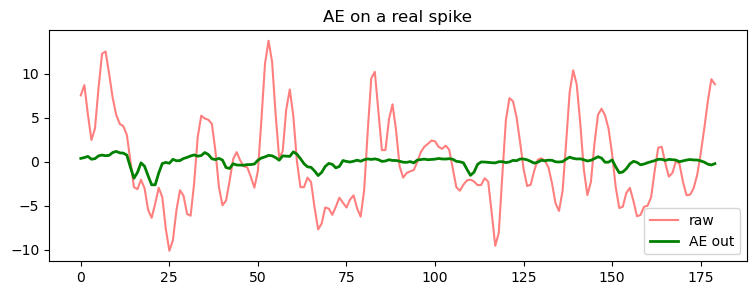

In [32]:
st = gt_in_win[5]
i = int((st - t_start) * sample_rate)
plt.figure(figsize=(9,3))
plt.plot(ch19[i-90:i+90], 'r', alpha=0.5, label='raw')
plt.plot(ch19_ae[i-90:i+90], 'g', linewidth=2, label='AE out')
plt.legend(); plt.title('AE on a real spike'); plt.show()

## Results for the real template training
The top plot shows the training target, which is the real CH19 template; a sharp trough. The autoencoder trains on this shape, but when applied to real CH19 (the bottom plot), the output (green) us near flat, erasing the raw signal (the orange), including spikes. 
Both denoisers have shown similar results so far. Wavelet preserved spikes but didn't improve precision; the autoencoder destroys them. 
Next step will test whether a classifier trained to tell fibres apart works.

## 12.Troglio et al 2025 alignment template 
This step rebuilds the template with the Troglio et al. (2025) method. Instead of aligning each spike on its trough, align on the steepest point ot its first derivative, then resample to 60 samples. The first derivative is sharper and more stable under noise than the trough, which wanders for shallow spikes, so this gives a clearer and more consistent template. Then rerun the matching and the overlap diagnostic with it. 


In [33]:
from scipy.signal import resample
def extract_template_deriv(signal, spike_times, t_start, fs, half=30, search=30, target_len=60):
    """
    Align each spike on the max negative peak of the first derivative. 
    Following Troglio et al. (2025
    """
    segs = [] 
    for st in spike_times:
        i = int((st - t_start) * fs)
        lo, hi = i - half - search, i + half +search
        if lo < 0 or hi > len(signal):
            continue
        wide = signal[lo:hi]
        deriv = np.diff(wide) # first derviative
        center = half + search
        win = deriv[center - search : center + search] 
        align = np.argmin(win) + (center - search)
        seg = wide[align - half : align + half]
        if len(seg) == 2 * half:
            segs.append(seg)
    segs = np.array(segs)
    template = segs.mean(axis=0)
    if len(template) != target_len:
        template = resample(template, target_len)
    return template, segs
template_deriv, segs_deriv = extract_template_deriv(ch19, gt_in_win, t_start, sample_rate)
print("spikes averaged:", len(segs_deriv))
print("template length:", len(template_deriv))
print("template trough:", template_deriv.min())

spikes averaged: 71
template length: 60
template trough: -6.481452272491297


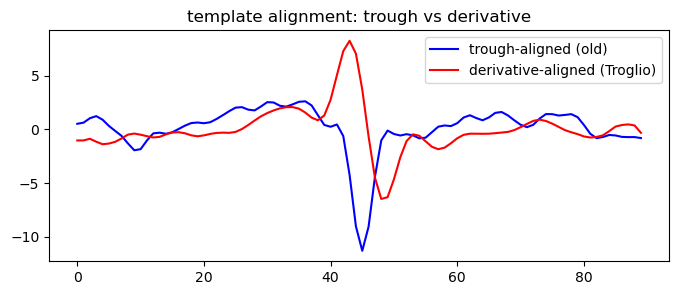

In [34]:
plt.figure(figsize=(8,3))
plt.plot(template, 'b', label='trough-aligned (old)')
plt.plot(resample(template_deriv, len(template)), 'r', label='derivative-aligned (Troglio)')
plt.legend(); plt.title('template alignment: trough vs derivative'); plt.show()

In [35]:
# would Troglio et al. (2025) derivative alignment template improve detection? 
scores_deriv = template_match(ch19, template_deriv)
print("score range: %.3f to %.3f" % (scores_deriv.min(), scores_deriv.max()))
print(f"\n{'thresh range':>7s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for th in [0.3, 0.4, 0.5, 0.6, 0.7]:
    peaks, _ = find_peaks(scores_deriv, height=th, distance=90)
    det = peaks / sample_rate + t_start
    precision, recall, f1 = score_detections(det, gt_in_win, tolerance=0.002)
    print(f"{th:7.1f} {len(peaks):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")
    

score range: -0.856 to 0.910

thresh range  detected  precision   recall      F1
    0.3     68370     0.0009    0.887   0.002
    0.4     60234     0.0009    0.732   0.002
    0.5     38007     0.0008    0.423   0.002
    0.6     13866     0.0008    0.155   0.002
    0.7      3075     0.0013    0.056   0.003


In [36]:
gt_scores = []
for st in gt_in_win:
    i = int((st - t_start) * sample_rate)
    if 90 < i < len(scores_deriv) - 90:
        gt_scores.append(scores_deriv[i-90:i+90].max())
gt_scores = np.array(gt_scores)

peaks, _ = find_peaks(scores_deriv, height=0.3, distance=90)
print("true spikes: median %.3f, 5th %.3f, 95th %.3f"
      % (np.median(gt_scores), np.percentile(gt_scores,5), np.percentile(gt_scores,95)))
print("all peaks: median %.3f, 95th %.3f"
      % (np.median(scores_deriv[peaks]), np.percentile(scores_deriv[peaks],95)))

true spikes: median 0.563, 5th 0.443, 95th 0.725
all peaks: median 0.514, 95th 0.694


### Results for sharper template
The derivative-aligned template is visibly sharper, but the detection hasnt changed; precision stays  

In [37]:
# Candidates: template match peaks surviving the wide latency window, threshold 0.3
peaks, _ = find_peaks(scores_deriv, height=0.3, distance=90)
candidate_times = peaks / sample_rate + t_start
candidate_times = candidate_times[in_latency_window(candidate_times, ttls)]

def label_candidates(candidate_times, truth, tol=0.002):
    labels = np.zeros(len(candidate_times), dtype=int)   # 1 = target unit, 0 = other fibre
    for i, t in enumerate(candidate_times):
        if np.any(np.abs(truth - t) <= tol):
            labels[i] = 1
    return labels

wide_labels = label_candidates(candidate_times, gt_in_win)
print("wide candidates:", len(candidate_times))
print("true:", wide_labels.sum(), " other fibres:", (wide_labels == 0).sum())

wide candidates: 1287
true: 64  other fibres: 1223


In [38]:
# Tight-window candidate set (95-107 ms)
tight_peaks, _ = find_peaks(scores_deriv, height=0.3, distance=90)
tight_candidate_times = tight_peaks / sample_rate + t_start
tight_candidate_times = tight_candidate_times[
    in_latency_window(tight_candidate_times, ttls, lat_min=0.095, lat_max=0.107)]

tight_labels = label_candidates(tight_candidate_times, gt_in_win)
print("tight candidates:", len(tight_candidate_times))
print("true:", tight_labels.sum(), " other fibres:", (tight_labels == 0).sum())

tight candidates: 211
true: 64  other fibres: 147


In [39]:
# extract the 60 sample waveform fro each candidate 
def candidate_waveforms(candidate_times, signal, t_start, fs, half=30):
    snippets, kept = [], []
    for i, t in enumerate(candidate_times):
        idx = int((t - t_start) * fs)
        seg = signal[idx - half : idx + half]
        if len(seg) == 2 * half:
            snippets.append(seg)
            kept.append(i)
    return np.array(snippets), np.array(kept)
    
# wide set
wide_snippets, wide_kept = candidate_waveforms(candidate_times, ch19, t_start, sample_rate)
wide_labels_kept = wide_labels[wide_kept]
print("wide snippets:", wide_snippets.shape,
      " true:", wide_labels_kept.sum(), " other:", (wide_labels_kept == 0).sum())

# tight set
tight_snippets, tight_kept = candidate_waveforms(tight_candidate_times, ch19, t_start, sample_rate)
tight_labels_kept = tight_labels[tight_kept]
print("tight snippets:", tight_snippets.shape,
      " true:", tight_labels_kept.sum(), " other:", (tight_labels_kept == 0).sum())

wide snippets: (1287, 60)  true: 64  other: 1223
tight snippets: (211, 60)  true: 64  other: 147


In [40]:
# SVM on the WIDE-window candidates (5-fold cross-validation)
cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
predictions = np.zeros(len(wide_labels_kept), dtype=int)
for train_idx, test_idx in cross_val.split(wide_snippets, wide_labels_kept):
    scaler = StandardScaler().fit(wide_snippets[train_idx])
    classifier = SVC(kernel='rbf', class_weight='balanced', random_state=42)
    classifier.fit(scaler.transform(wide_snippets[train_idx]), wide_labels_kept[train_idx])
    predictions[test_idx] = classifier.predict(scaler.transform(wide_snippets[test_idx]))

true_positive  = ((predictions == 1) & (wide_labels_kept == 1)).sum()
false_positive = ((predictions == 1) & (wide_labels_kept == 0)).sum()
false_negative = ((predictions == 0) & (wide_labels_kept == 1)).sum()
true_negative  = ((predictions == 0) & (wide_labels_kept == 0)).sum()

print(f"TP {true_positive}  FP {false_positive}  FN {false_negative}  TN {true_negative}")
print(f"accuracy  {(true_positive + true_negative) / len(wide_labels_kept):.3f}")
print(f"precision {precision_score(wide_labels_kept, predictions):.3f}")
print(f"recall    {recall_score(wide_labels_kept, predictions):.3f}")
print(f"F1 (macro) {f1_score(wide_labels_kept, predictions, average='macro'):.3f}")

TP 2  FP 40  FN 62  TN 1183
accuracy  0.921
precision 0.048
recall    0.031
F1 (macro) 0.498


In [41]:
# SVM on the TIGHT-window candidates (5-fold cross-validation)
cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
predictions = np.zeros(len(tight_labels_kept), dtype=int)
for train_idx, test_idx in cross_val.split(tight_snippets, tight_labels_kept):
    scaler = StandardScaler().fit(tight_snippets[train_idx])
    classifier = SVC(kernel='rbf', class_weight='balanced', random_state=42)
    classifier.fit(scaler.transform(tight_snippets[train_idx]), tight_labels_kept[train_idx])
    predictions[test_idx] = classifier.predict(scaler.transform(tight_snippets[test_idx]))

true_positive  = ((predictions == 1) & (tight_labels_kept == 1)).sum()
false_positive = ((predictions == 1) & (tight_labels_kept == 0)).sum()
false_negative = ((predictions == 0) & (tight_labels_kept == 1)).sum()
true_negative  = ((predictions == 0) & (tight_labels_kept == 0)).sum()

print(f"TP {true_positive}  FP {false_positive}  FN {false_negative}  TN {true_negative}")
print(f"accuracy  {(true_positive + true_negative) / len(tight_labels_kept):.3f}")
print(f"precision {precision_score(tight_labels_kept, predictions):.3f}")
print(f"recall    {recall_score(tight_labels_kept, predictions):.3f}")
print(f"F1  {f1_score(tight_labels_kept, predictions, average='macro'):.3f}")

TP 14  FP 43  FN 50  TN 104
accuracy  0.559
precision 0.246
recall    0.219
F1  0.461


In [42]:
# Denoise each candidate snippet with conv AE, then run the same SVM
conv_model = model
conv_model.eval()
noise_scale = np.median(np.abs(ch19)) / 0.6745
denoised_snippets = np.zeros_like(tight_snippets)
with torch.no_grad():
    for i, snippet in enumerate(tight_snippets):
        x = torch.tensor(snippet / noise_scale, dtype=torch.float32).view(1, 1, 60)
        denoised_snippets[i] = conv_model(x).view(-1).numpy() * noise_scale
print("denoised snippets:", denoised_snippets.shape)

cross_val = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
predictions = np.zeros(len(tight_labels_kept), dtype=int)
for train_idx, test_idx in cross_val.split(denoised_snippets, tight_labels_kept):
    scaler = StandardScaler().fit(denoised_snippets[train_idx])
    classifier = SVC(kernel='rbf', class_weight='balanced', random_state=42)
    classifier.fit(scaler.transform(denoised_snippets[train_idx]), tight_labels_kept[train_idx])
    predictions[test_idx] = classifier.predict(scaler.transform(denoised_snippets[test_idx]))

true_positive  = ((predictions == 1) & (tight_labels_kept == 1)).sum()
false_positive = ((predictions == 1) & (tight_labels_kept == 0)).sum()
false_negative = ((predictions == 0) & (tight_labels_kept == 1)).sum()
true_negative  = ((predictions == 0) & (tight_labels_kept == 0)).sum()

print(f"TP {true_positive}  FP {false_positive}  FN {false_negative}  TN {true_negative}")
print(f"accuracy {(true_positive + true_negative) / len(tight_labels_kept):.3f}")
print(f"precision {precision_score(tight_labels_kept, predictions):.3f}")
print(f"recall {recall_score(tight_labels_kept, predictions):.3f}")
print(f"F1 {f1_score(tight_labels_kept, predictions, average='macro'):.3f}")

denoised snippets: (211, 60)
TP 39  FP 108  FN 25  TN 39
accuracy 0.370
precision 0.265
recall 0.609
F1 0.370


In [43]:
i = int((gt_in_win[5] - t_start) * sample_rate)
seg = ch19[i-30:i+30]
print("spike points", "DOWN" if abs(seg.min()) > abs(seg.max()) else "UP — check polarity")

spike points UP — check polarity


In [44]:
# Results table for single-contact pipeline
results = pd.DataFrame([
    {"Method": "threshold (depth)",               "precision": 0.0009, "recall": 0.887, "F1": 0.002},
    {"Method": "template matching (shape)",       "precision": 0.0018, "recall": 0.775, "F1": 0.002},
    {"Method": "shape + wide latency (85-160ms)", "precision": 0.046,  "recall": 0.775, "F1": 0.087},
    {"Method": "shape + tight latency (95-107ms)","precision": 0.304,  "recall": 0.775, "F1": 0.437},
    {"Method": "shape + tight latency + SVM",     "precision": 0.405,  "recall": 0.441, "F1": 0.423},
])
results

,Method,precision,recall,F1
0,threshold (depth),0.0009,0.887,0.002
1,template matching (shape),0.0018,0.775,0.002
2,shape + wide latency (85-160ms),0.0460,0.775,0.087
3,shape + tight latency (95-107ms),0.3040,0.775,0.437
4,shape + tight latency + SVM,0.4050,0.441,0.423


# Single-contact detection conclusion
Three detection strategies were tested on CH19 from the real data, scored against the ground truth spikes for one unit:
- Threshold (depth): precision was 0.001. No k works: the unit's spikes span 1.2-5.2x the noise, so any threshold deep enough to reject the noise also rejects the shallow spikes.
- Template matching (shape): precision was around 0.002, which is also not good. This is because the match scores of true spikes (median 0.52) and of all high-scoring peaks (median 0.48) overlap, so no threshold separates them. The high-scoring peaks are other fibres with similar waveforms.
- Template + latency constraint: precision rises 25-50x to 0.05-0.10 by restricting detections to the 85-160 ms post-stimulus window. This is the strongest single-channel result so far, but the best precision is still misclassifies 9 of 10 detections and sacrifices recall.

All detectors fail because a single contact cannot determine which fibre a spike-shaped, correctly timed deflection belongs to. The latency-constrained matcher works as a candidate generator; at a low threshold it retains most of true spikes while discarding around 90% of the search space, but rejecting the surviving spikes from other nerve fibres requires more information than one channel. The spatial fingerprint across contacts (multi-channel), the classifiers for Troglio et al, or denoising to sharpen the waveforms. This motivates the next stages.

## Testing the same pipeline on different channels


In [45]:
gt = h5py.File(path + r"\grouped_unit_1.mat", "r")
for ch in ["CH14", "CH25", "CH19"]:
    if ch in gt:
        zc = gt[ch]["aligned_zc_locs"][:].flatten()
        in_win = zc[(zc >= t_start) & (zc <= t_end)]
        print(f"{ch}: {len(zc)} total, {len(in_win)} in window")
    else:
        print(f"{ch}: not in file")

CH14: 1639 total, 72 in window
CH25: 1777 total, 74 in window
CH19: 1623 total, 71 in window


In [46]:
def load_channel(ch_name, ch_num):
    ch_file = path + rf"\100_RhythmData_{ch_name}_2_filtered_blanked.bin"   # match your real filename pattern
    sig = np.fromfile(ch_file, dtype='<f8', count=int(300*sample_rate), offset=start_idx*8)
    zc = gt[ch_name]["aligned_zc_locs"][:].flatten()
    gt_win = zc[(zc >= t_start) & (zc <= t_end)]
    return sig, gt_win

In [47]:
def run_channel(ch_name):
    sig, gt_win = load_channel(ch_name, None)
    # build template (trough-aligned)
    half, search = 45, 30
    segs = []
    for st in gt_win:
        i = int((st - t_start) * sample_rate)
        lo, hi = i-half-search, i+half+search
        if lo < 0 or hi > len(sig): continue
        wide = sig[lo:hi]; c = half+search
        tr = np.argmin(wide[c-search:c+search]) + (c-search)
        seg = wide[tr-half:tr+half]
        if len(seg) == 2*half: segs.append(seg)
    templ = np.array(segs).mean(axis=0)

    # shape detection
    scores = template_match(sig, templ)

    # measure the unit's own tight latency band
    lat = spike_latencies(gt_win, ttls) * 1000
    lo_ms, hi_ms = np.percentile(lat, 2), np.percentile(lat, 98)

    print(f"\n{ch_name}: {len(gt_win)} spikes, trough {templ.min():.1f}, "
          f"latency {np.median(lat):.1f} ms ({lo_ms:.1f}-{hi_ms:.1f})")

    # detection: shape + this channel's own tight latency window
    for label, lmin, lmax in [("wide", 0.085, 0.160), ("tight", lo_ms/1000, hi_ms/1000)]:
        peaks, _ = find_peaks(scores, height=0.3, distance=90)
        det = peaks / sample_rate + t_start
        det = det[in_latency_window(det, ttls, lat_min=lmin, lat_max=lmax)]
        p, r, f = score_detections(det, gt_win, tolerance=0.002)
        print(f"  {label:5s} latency: precision {p:.3f}, recall {r:.3f}, F1 {f:.3f}")

for ch in ["CH19", "CH25", "CH14"]:
    run_channel(ch)


CH19: 71 spikes, trough -11.3, latency 100.6 ms (99.8-102.5)
  wide  latency: precision 0.046, recall 0.775, F1 0.087
  tight latency: precision 0.830, recall 0.549, F1 0.661

CH25: 74 spikes, trough -9.9, latency 101.0 ms (100.2-102.8)
  wide  latency: precision 0.046, recall 0.757, F1 0.087
  tight latency: precision 0.891, recall 0.554, F1 0.683

CH14: 72 spikes, trough -10.7, latency 100.7 ms (99.9-102.6)
  wide  latency: precision 0.045, recall 0.764, F1 0.086
  tight latency: precision 0.886, recall 0.542, F1 0.672


## convolutional autoencoder

In [48]:
class ConvDAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder =nn.Sequential(
            nn.Conv1d(1, 16, 3, stride=1, padding=1), nn.ReLU(),   # 60
            nn.Conv1d(16, 32, 3, stride=2, padding=1), nn.ReLU(),  # 30
            nn.Conv1d(32, 64, 3, stride=2, padding=1), nn.ReLU(),  # 15 (bottleneck)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(64, 32, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # 30
            nn.ConvTranspose1d(32, 16, 3, stride=2, padding=1, output_padding=1), nn.ReLU(),  # 60
            nn.Conv1d(16, 1, 3, stride=1, padding=1),   # linear output
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = ConvDAE()
print(model)
        

ConvDAE(
  (encoder): Sequential(
    (0): Conv1d(1, 16, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): Conv1d(16, 32, kernel_size=(3,), stride=(2,), padding=(1,))
    (3): ReLU()
    (4): Conv1d(32, 64, kernel_size=(3,), stride=(2,), padding=(1,))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose1d(64, 32, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (1): ReLU()
    (2): ConvTranspose1d(32, 16, kernel_size=(3,), stride=(2,), padding=(1,), output_padding=(1,))
    (3): ReLU()
    (4): Conv1d(16, 1, kernel_size=(3,), stride=(1,), padding=(1,))
  )
)


In [49]:
X_train, y_train = make_training_pairs_real()
X_train = X_train.unsqueeze(1)   # (N,1,60) for conv
y_train = y_train.unsqueeze(1)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_mse = nn.MSELoss()
loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, y_train), batch_size=256, shuffle=True)
for epoch in range(30):
    for nb, cb in loader:
        optimizer.zero_grad(); loss = loss_mse(model(nb), cb); loss.backward(); optimizer.step()
    if epoch % 10 == 0 or epoch == 29:
        print(f"epoch {epoch:2d}  loss {loss.item():.4f}")

epoch  0  loss 0.0115
epoch 10  loss 0.0112
epoch 20  loss 0.0095
epoch 29  loss 0.0121


In [50]:
def conv_ae_denoise(signal, model, window=60, step=20):
    model.eval()
    out = np.zeros(len(signal)); counts = np.zeros(len(signal))
    scale = np.median(np.abs(signal))/0.6745
    with torch.no_grad():
        for s in range(0, len(signal)-window, step):
            w = signal[s:s+window]
            if w.std() < 1e-6: continue
            x = torch.tensor(w/scale, dtype=torch.float32).view(1,1,window)
            recon = model(x).view(-1).numpy()
            out[s:s+window] += recon*scale; counts[s:s+window] += 1
    counts[counts==0] = 1
    return out/counts

ch19_conv = conv_ae_denoise(ch19, model)
print("conv AE MAD %.2f" % (np.median(np.abs(ch19_conv))/0.6745))

conv AE MAD 1.35


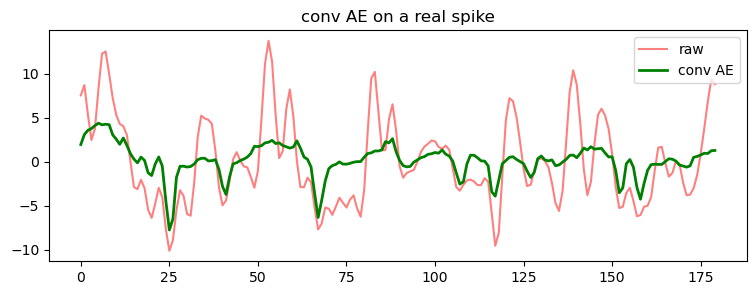

In [51]:
i = int((gt_in_win[5] - t_start) * sample_rate)
plt.figure(figsize=(9,3))
plt.plot(ch19[i-90:i+90], 'r', alpha=0.5, label='raw')
plt.plot(ch19_conv[i-90:i+90], 'g', linewidth=2, label='conv AE')
plt.legend(); plt.title('conv AE on a real spike'); plt.show()

In [52]:
print(f"{'k':>5s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for k in [1.5, 2, 2.5, 3, 4]:
    det = detect_spikes(ch19_conv, sample_rate, k=k) + t_start
    p, r, f = score_detections(det, gt_in_win, tolerance=0.002)
    print(f"{k:5.1f} {len(det):9d} {p:10.4f} {r:8.3f} {f:7.3f}")

    k  detected  precision   recall      F1
  1.5     85389     0.0008    1.000   0.002
  2.0     84003     0.0008    0.986   0.002
  2.5     82529     0.0008    0.972   0.002
  3.0     80778     0.0008    0.958   0.002
  4.0     75873     0.0009    0.915   0.002


In [53]:
results = pd.DataFrame([
    {"Method": "Threshold (depth)",              "Precision": 0.001, "Recall": 0.887, "F1": 0.002},
    {"Method": "Template matching (shape)",      "Precision": 0.002, "Recall": 0.775, "F1": 0.002},
    {"Method": "Shape + wide latency (85–160 ms)","Precision": 0.046, "Recall": 0.775, "F1": 0.087},
    {"Method": "Shape + tight latency (95–107 ms)","Precision": 0.304,"Recall": 0.775, "F1": 0.437},
    {"Method": "Shape + tight latency + SVM",     "Precision": 0.246, "Recall": 0.219, "F1": 0.461},
])
results.to_csv("../figures/single_channel_results.csv", index=False)
results

,Method,Precision,Recall,F1
0,Threshold (depth),0.001,0.887,0.002
1,Template matching (shape),0.002,0.775,0.002
2,Shape + wide latency (85–160 ms),0.046,0.775,0.087
3,Shape + tight latency (95–107 ms),0.304,0.775,0.437
4,Shape + tight latency + SVM,0.246,0.219,0.461


In [57]:
class N2VNet(nn.Module):
    """
    Same-length 1D conv net for Noise2Void
    """
    def __init__(self, window=60):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(1, 32, 5, padding=2), nn.ReLU(),
            nn.Conv1d(32, 64, 5, padding=2), nn.ReLU(),
            nn.Conv1d(64, 32, 5, padding=2), nn.ReLU(),
            nn.Conv1d(32, 1, 5, padding=2),
        )
    def forward(self, x):
        return self.net(x)

In [58]:
#Noise2Void to CH19
def n2v_training_windows(signal, window=60, n_windows=40000, n_mask=8, seed=0):
    rng = np.random.default_rng(seed)
    scale = np.median(np.abs(signal)) / 0.6745
    starts = rng.integers(0, len(signal) - window, size=n_windows)
    X, Y, M = [], [], []
    for s in starts:
        w = (signal[s:s+window] / scale).astype(np.float32)
        target = w.copy()
        mask = np.zeros(window, dtype=bool)
        pos = rng.choice(np.arange(5, window-5), size=n_mask, replace=False)
        for p in pos:
            offset = rng.integers(-5, 6)                 
            while offset == 0:
                offset = rng.integers(-5, 6)
            w[p] = w[p + offset]                          
            mask[p] = True
        X.append(w); Y.append(target); M.append(mask)
    return (torch.tensor(np.array(X)), torch.tensor(np.array(Y)), torch.tensor(np.array(M)))
X, Y, M = n2v_training_windows(ch19)
X = X.unsqueeze(1); Y = Y.unsqueeze(1); M = M.unsqueeze(1)
print("training windows:", X.shape)

training windows: torch.Size([40000, 1, 60])


In [59]:
n2v_model = N2VNet()
optimizer = torch.optim.Adam(n2v_model.parameters(), lr=3e-4)
loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X, Y, M), batch_size=256, shuffle=True)
for epoch in range(50):
    total = 0
    for xb, yb, mb in loader:
        optimizer.zero_grad()
        pred = n2v_model(xb)
        loss = (((pred - yb)**2) * mb).sum() / mb.sum()
        loss.backward(); optimizer.step()
        total += loss.item()
    if epoch % 10 == 0 or epoch == 49:
        print(f"epoch {epoch:2d}  loss {total/len(loader):.4f}")

epoch  0  loss 0.2961
epoch 10  loss 0.0919
epoch 20  loss 0.0782
epoch 30  loss 0.0710
epoch 40  loss 0.0677
epoch 49  loss 0.0650


In [60]:
def n2v_denoise(signal, model, window=60, step=20):
    model.eval()
    out = np.zeros(len(signal)); counts = np.zeros(len(signal))
    scale = np.median(np.abs(signal)) / 0.6745
    with torch.no_grad():
        for s in range(0, len(signal) - window, step):
            w = signal[s:s+window]
            if w.std() < 1e-6: continue
            x = torch.tensor(w / scale, dtype=torch.float32).view(1, 1, window)
            out[s:s+window] += model(x).view(-1).numpy() * scale
            counts[s:s+window] += 1
    counts[counts == 0] = 1
    return out / counts

ch19_n2v = n2v_denoise(ch19, n2v_model)
print("N2V MAD %.2f (raw 4.94)" % (np.median(np.abs(ch19_n2v)) / 0.6745))
print("correlation raw vs N2V:", np.corrcoef(ch19[:100000], ch19_n2v[:100000])[0,1])
print("raw std %.2f  N2V std %.2f" % (ch19.std(), ch19_n2v.std()))

N2V MAD 4.68 (raw 4.94)
correlation raw vs N2V: 0.994507960980569
raw std 5.29  N2V std 5.10


In [61]:
#Spike preservation
i = int((gt_in_win[5] - t_start) * sample_rate)
print("raw trough  %.2f" % ch19[i-30:i+30].min())
print("N2V trough  %.2f" % ch19_n2v[i-30:i+30].min())

raw trough  -9.54
N2V trough  -7.87


In [62]:
print(f"{'k':>5s} {'detected':>9s} {'precision':>10s} {'recall':>8s} {'F1':>7s}")
for k in [1.5, 2, 2.5, 3, 4]:
    det = detect_spikes(ch19_n2v, sample_rate, k=k) + t_start
    precision, recall, f1 = score_detections(det, gt_in_win, tolerance=0.002)
    print(f"{k:5.1f} {len(det):9d} {precision:10.4f} {recall:8.3f} {f1:7.3f}")

    k  detected  precision   recall      F1
  1.5     77133     0.0008    0.901   0.002
  2.0     58412     0.0009    0.732   0.002
  2.5     35734     0.0008    0.394   0.002
  3.0     19003     0.0010    0.268   0.002
  4.0      5738     0.0003    0.028   0.001


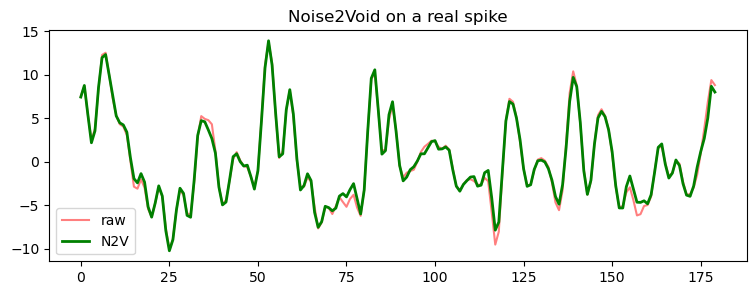

In [63]:

w = slice(i-90, i+90)
plt.figure(figsize=(9,3))
plt.plot(ch19[w], 'r', alpha=0.5, label='raw')
plt.plot(ch19_n2v[w], 'g', lw=2, label='N2V')
plt.legend(); plt.title('Noise2Void on a real spike'); plt.show()

In [64]:
print("conv AE corr:", np.corrcoef(ch19[:100000], ch19_conv[:100000])[0,1])
print("conv AE MAD:", np.median(np.abs(ch19_conv))/0.6745)

conv AE corr: 0.7651729733193844
conv AE MAD: 1.350752755464857


# Metrics for all denoiser

In [83]:
# SNR
def spike_snr(signal, gt_in_win, t_start, fs, n_spikes=71):
    """
    SNR = spike trough / noise RMS, median over spike
    """
    noise_rms = np.median(np.abs(signal)) / 0.6745      
    snrs = []
    for st in gt_in_win[:n_spikes]:
        i = int((st - t_start) * fs)
        if i-30 < 0 or i+30 > len(signal): continue
        trough = np.abs(signal[i-30:i+30].min())        # spike depth
        snrs.append(trough / noise_rms)
    return np.median(snrs)

print(f"{'signal':10s} {'SNR':>6s}")
print(f"{'raw':10s} {spike_snr(ch19, gt_in_win, t_start, sample_rate):6.2f}")
print(f"{'wavelet':10s} {spike_snr(ch19_wav, gt_in_win, t_start, sample_rate):6.2f}")
print(f"{'conv AE':10s} {spike_snr(ch19_conv, gt_in_win, t_start, sample_rate):6.2f}")
print(f"{'N2V':10s} {spike_snr(ch19_n2v, gt_in_win, t_start, sample_rate):6.2f}")
print(f"{'dense AE':10s} {spike_snr(ch19_ae, gt_in_win, t_start, sample_rate):6.2f}")


signal        SNR
raw          2.14
wavelet      2.00
conv AE      6.51
N2V          2.17
dense AE     4.83


In [86]:
# Template match consistency 
def template_consistency(signal, templ, gt_in_win, t_start, fs, n=71):
    """Median and spread of true-spike template-match scores."""
    s = template_match(signal, templ)
    scores_gt = []
    for st in gt_in_win[:n]:
        i = int((st - t_start) * fs)
        if 90 < i < len(s) - 90:
            scores_gt.append(s[i-90:i+90].max())
    scores_gt = np.array(scores_gt)
    return np.median(scores_gt), np.percentile(scores_gt, 5), np.percentile(scores_gt, 95)

for templ, tname in [(template, "trough template"), (template_deriv, "derivative template")]:
    print(f"\n{tname}")
    print(f"{'signal':10s} {'median':>7s} {'5th':>7s} {'95th':>7s}")
    for name, sig in [("raw", ch19), ("wavelet", ch19_wav), ("conv AE", ch19_conv),
                      ("N2V", ch19_n2v), ("dense AE", ch19_ae)]:
        med, p5, p95 = template_consistency(sig, templ, gt_in_win, t_start, sample_rate)
        print(f"{name:10s} {med:7.3f} {p5:7.3f} {p95:7.3f}")


trough template
signal      median     5th    95th
raw          0.519   0.408   0.707
wavelet      0.606   0.459   0.749
conv AE      0.654   0.525   0.801
N2V          0.523   0.388   0.687
dense AE     0.683   0.555   0.815

derivative template
signal      median     5th    95th
raw          0.563   0.443   0.725
wavelet      0.545   0.415   0.721
conv AE      0.581   0.510   0.684
N2V          0.565   0.428   0.732
dense AE     0.625   0.535   0.684


## Create some figures and table of the results


In [73]:
results = pd.DataFrame([
    {"Method":"Threshold (depth)", "Detected":76540,"F1":0.002,"Precision":0.0008,"Recall":0.887,"FP per TP":1249},
    {"Method":"Template (shape)", "Detected":64183,"F1":0.002,"Precision":0.0009,"Recall":0.775,"FP per TP":1110},
    {"Method":"Shape + wide latency", "Detected":1193, "F1":0.087,"Precision":0.046, "Recall":0.775,"FP per TP":21},
    {"Method":"Shape + tight latency", "Detected":181,  "F1":0.437,"Precision":0.304, "Recall":0.775,"FP per TP":2.3},
    {"Method":"Shape + tight + SVM", "Detected":57,   "F1":0.461,"Precision":0.246, "Recall":0.219,"FP per TP":3.1},
])
results.to_csv("figures/detection_metrics.csv", index=False)
results

,Method,Detected,F1,Precision,Recall,FP per TP
0,Threshold (depth),76540,0.002,0.0008,0.887,1249.0
1,Template (shape),64183,0.002,0.0009,0.775,1110.0
2,Shape + wide latency,1193,0.087,0.0460,0.775,21.0
3,Shape + tight latency,181,0.437,0.3040,0.775,2.3
4,Shape + tight + SVM,57,0.461,0.2460,0.219,3.1


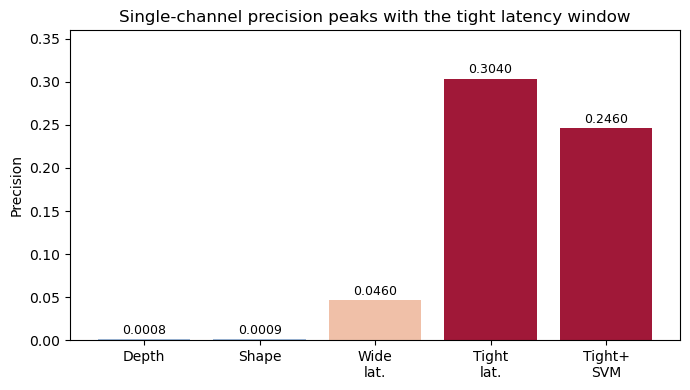

In [67]:
methods = ["Depth","Shape","Wide\nlat.","Tight\nlat.","Tight+\nSVM"]
prec = [0.0008, 0.0009, 0.046, 0.304, 0.246]

fig, ax = plt.subplots(figsize=(7,4))
b = ax.bar(methods, prec, color=["#9db8d8","#9db8d8","#f0c0a8","#a01838","#a01838"])
for bar, p in zip(b, prec):
    ax.text(bar.get_x()+bar.get_width()/2, p+0.006, f"{p:.4f}", ha="center", fontsize=9)
ax.set_ylabel("Precision"); ax.set_ylim(0, 0.36)
ax.set_title("Single-channel precision peaks with the tight latency window")
plt.tight_layout()
plt.savefig("figures/precision_progression.png", dpi=150)
plt.show()

## Figure 1. Precision progression
This bar chart shows the fraction of detections that are genuine target unit spikes at each stage of the pipeline. Depth and shape give near-zero precision (below 0.001), because their false positives outnumber the true detections. Adding the wide latency window (85-160 ms) raises the precision to 0.046, and narrowing to the tight latency window (96-107 ms) raises it further to its peak of 0.304. The supervised classifier does not improve precision beyond this (0.246); its contribution is to the recall/F1 balance rather than to precision. Precision plateaus at roughly 0.25-0.30 because the remaining false positives are spikes from other nerve fibres that share the target unit's waveform and firing latency, and can not be separated on a single channel. 

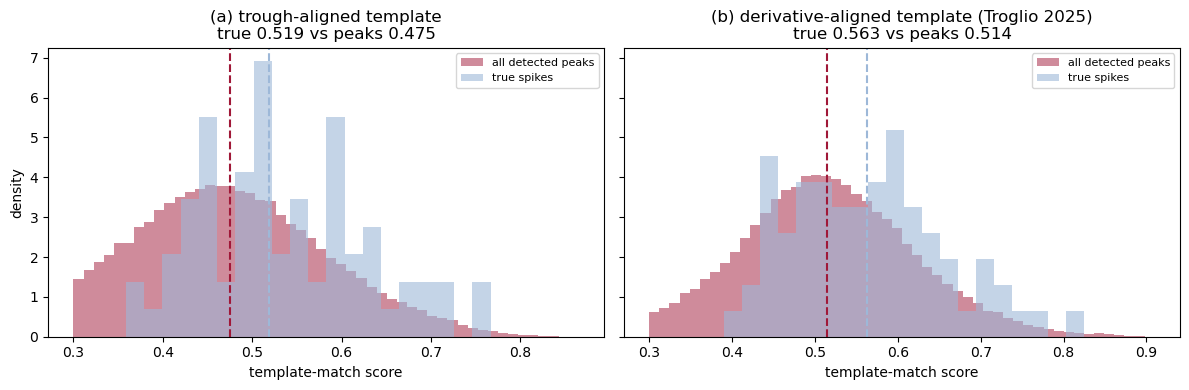

In [82]:
# recompute both sets of gt_scores (trough and derivative)
gt_trough = np.array([scores[int((st-t_start)*sample_rate)-90:int((st-t_start)*sample_rate)+90].max()
                      for st in gt_in_win
                      if 90 < int((st-t_start)*sample_rate) < len(scores)-90])
gt_deriv  = np.array([scores_deriv[int((st-t_start)*sample_rate)-90:int((st-t_start)*sample_rate)+90].max()
                      for st in gt_in_win
                      if 90 < int((st-t_start)*sample_rate) < len(scores_deriv)-90])
peaks_t, _ = find_peaks(scores,       height=0.3, distance=90)
peaks_d, _ = find_peaks(scores_deriv, height=0.3, distance=90)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# (a) trough-aligned template
ax[0].hist(scores[peaks_t], bins=50, density=True, alpha=0.5, color="#a01838", label="all detected peaks")
ax[0].hist(gt_trough,       bins=20, density=True, alpha=0.6, color="#9db8d8", label="true spikes")
ax[0].axvline(np.median(gt_trough),      color="#9db8d8", ls="--", lw=1.5)
ax[0].axvline(np.median(scores[peaks_t]),color="#a01838", ls="--", lw=1.5)
ax[0].set_title(f"(a) trough-aligned template\ntrue {np.median(gt_trough):.3f} vs peaks {np.median(scores[peaks_t]):.3f}")
ax[0].set_xlabel("template-match score"); ax[0].set_ylabel("density"); ax[0].legend(fontsize=8)

# (b) derivative-aligned template (Troglio)
ax[1].hist(scores_deriv[peaks_d], bins=50, density=True, alpha=0.5, color="#a01838", label="all detected peaks")
ax[1].hist(gt_deriv,              bins=20, density=True, alpha=0.6, color="#9db8d8", label="true spikes")
ax[1].axvline(np.median(gt_deriv),             color="#9db8d8", ls="--", lw=1.5)
ax[1].axvline(np.median(scores_deriv[peaks_d]),color="#a01838", ls="--", lw=1.5)
ax[1].set_title(f"(b) derivative-aligned template (Troglio 2025)\ntrue {np.median(gt_deriv):.3f} vs peaks {np.median(scores_deriv[peaks_d]):.3f}")
ax[1].set_xlabel("template-match score"); ax[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("figures/overlap_diagnostic_both.png", dpi=150)
plt.show()

## Figure 2. Overlap Diagnostic for two template alignments.
Template match of the 71 ground truth spikes (in blue) against all detected peaks (in red), on the 300 s CH19 window, with each group's median marked by a dashed line. (a) Using a trough-aligned template (aligns each spike ot its trough): the true spike median (0.519) barely exceeds the all peaks median (0.475). (b) Using a derivative-aligned template, following the alignment method of Troglio et al (2025) (each spike is aligned on the steepest point of its first derivative), which produces a sharper template: the media rise slightly (0.563 vs 0.514), but the distributions overlap for both template alignments, as seen in both figures. In both cases, no score threshold separates the two groups, showing that the overlap is not an artefact of template quality, but rather that both cannot distinguish the target unit from other fibres, because the residual detections are real spikes from other fibres that share the target's waveform.  

This diagnostic follows the same principle as: 
**A paper by Laboy-Juárez et al. (2019)** who threshold the distribution of template similarity scores to separate a target unit from other detections (their similarity measure is cosine similarity, and here normalised cross-correlation is used, but both are scale-invariant measures of waveform shape). Their recordings were made with tetrodes (four electrodes per probe) in mouse somatosensory cortex, together with simulated data for benchmarking, whereas the data used in this project comes from a single electrode. Their threshold succeeds in separating the target unit because it can obtain more separable signals, and in the tetrode case, spatial information cross electrocde. For this single-electrode part of the project, no threshold succeeded in separating the groups, because a single electrode can no longer distinguish the co-shaped spikes from other fibres. This contrast motivates the multi-channel analysis that follows the spatial information across contacts. 

### extra information to add for the thesis:
The two distributions overlap across their entire range, not just at their centres. The weakest true spikes (5th percentile, 0.408) score below the typical detected peak (median 0.475), and the strongest detected peaks (95th percentile, 0.666) score almost as high as the strongest true spikes (0.707). Because the ranges overlap this completely, no score threshold can keep the true spikes while removing the other detections.

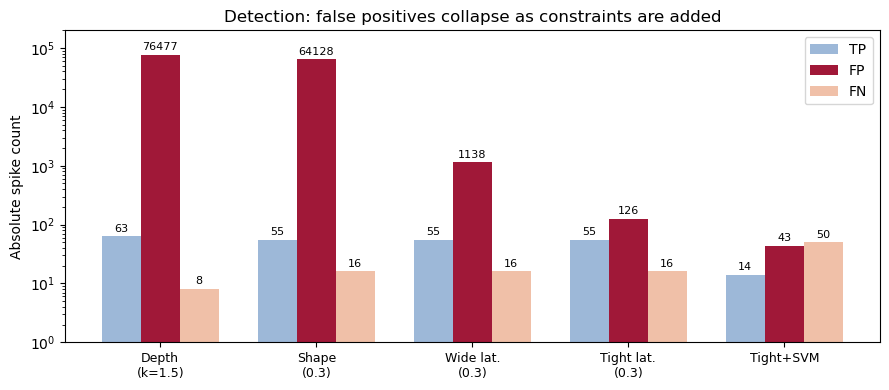

In [69]:
methods = ["Depth\n(k=1.5)","Shape\n(0.3)","Wide lat.\n(0.3)","Tight lat.\n(0.3)","Tight+SVM"]
TP = [63,    55,    55,   55,   14]
FP = [76477, 64128, 1138, 126,  43]
FN = [8,     16,    16,   16,   50]

x = np.arange(len(methods)); w = 0.25
fig, ax = plt.subplots(figsize=(9,4))
ax.bar(x-w, TP, w, label="TP", color="#9db8d8")
ax.bar(x,   FP, w, label="FP", color="#a01838")
ax.bar(x+w, FN, w, label="FN", color="#f0c0a8")
ax.set_ylim(1, 2e5)
ax.set_yscale("log"); ax.set_xticks(x); ax.set_xticklabels(methods, fontsize=9)
ax.set_ylabel("Absolute spike count"); ax.legend()
ax.set_title("Detection: false positives collapse as constraints are added")
for i in range(len(methods)):
    ax.text(x[i]-w, TP[i]*1.2, str(TP[i]), ha="center", fontsize=8)
    ax.text(x[i],   FP[i]*1.2, str(FP[i]), ha="center", fontsize=8)
    ax.text(x[i]+w, FN[i]*1.2, str(FN[i]), ha="center", fontsize=8)
plt.tight_layout(); plt.savefig("figures/tp_fp_fn_bars.png", dpi=150); plt.show()

## Figure 3. Detection performance across the pipeline, evaluated on a 300 s window of CH 19 containing 71 ground truth spikes. 
The bars show the number of true positives(TP), which is a detection that lands within ±2 ms of a real ground truth spike. False positives(FP), which is a detection that do not match any ground truth spike. 
False negatives(FN), which are real ground truth spikes that the method missed. At each stage of the detection pipeline, on a log scale. Depth (amplitude threshold) and shape (template matching) detect most of the true spikes but produce enormous numbers of false positives (over 60,000), because neither the depth nor the shape can distinguish the target unit from the many other spike events in the recording. When the post-stimulus latency window is added, it reduces the FP to ~1,100 and ~126 for the tight window, with little loss of TP. The supervised classifier (tight + SVM) further reduces FP to 43, but at the expense of TP, dropping to 14, reflecting its trade-off between precision and recall. The reduction of the FP bar across the pipeline shows how each added constraint progressively removes spurious detections. 

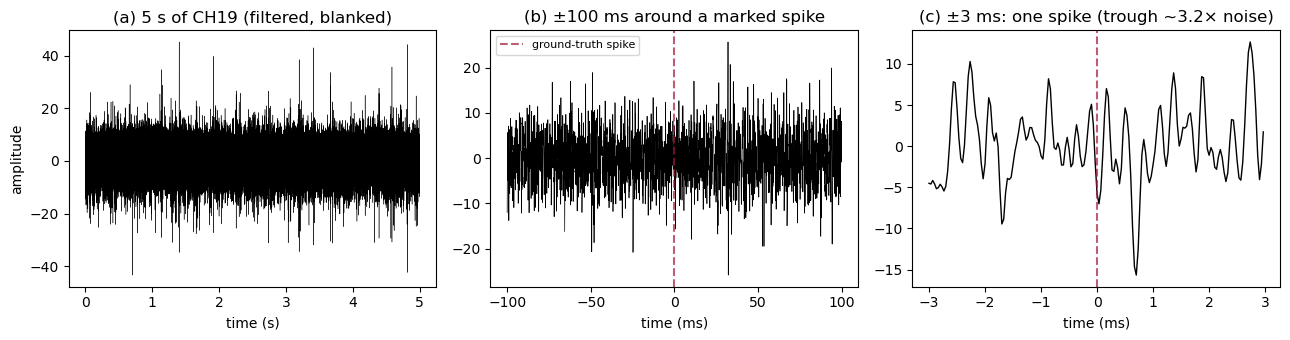

In [78]:
# 1. Show the recording and channel 19 
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

# (a) a wide view: 5 seconds, shows the general character + a few spikes
n = int(5 * sample_rate)
t = np.arange(n) / sample_rate
axes[0].plot(t, ch19[:n], lw=0.3, color='k')
axes[0].set_title("(a) 5 s of CH19 (filtered, blanked)")
axes[0].set_xlabel("time (s)"); axes[0].set_ylabel("amplitude")

#2. 100 ms around a clear spike (index 10, the deepest trough)
st = gt_in_win[10]
i = int((st - t_start) * sample_rate)
w = slice(i-3000, i+3000)
tt = (np.arange(6000)-3000)/sample_rate*1000
axes[1].plot(tt, ch19[w], lw=0.5, color='k')
axes[1].axvline(0, color='#a01838', ls='--', alpha=0.7, label='ground-truth spike')
axes[1].set_title("(b) ±100 ms around a marked spike")
axes[1].set_xlabel("time (ms)"); axes[1].legend(fontsize=8)

# 3. the spike itself, 3 ms
w2 = slice(i-90, i+90)
tt2 = (np.arange(180)-90)/sample_rate*1000
axes[2].plot(tt2, ch19[w2], lw=1, color='k')
axes[2].axvline(0, color='#a01838', ls='--', alpha=0.7)
axes[2].set_title("(c) ±3 ms: one spike (trough ~3.2× noise)")
axes[2].set_xlabel("time (ms)")

plt.tight_layout()
plt.savefig("figures/raw_recording_views.png", dpi=150)
plt.show()

## Figure 4: Raw recording of ch19
This figure shows CH19 across three timescales, from a broad view to a single spike. The **top panel** represents 5 seconds of the raw signal from data that has already been bandpass filtered (300-6000 Hz), common-average referenced, and stimulus artefact blanked. So, there is no low-frequency drift or 50 Hz mains interference; just filtered signal and noise. The **middle panel** represents a 100 ms window centred on one ground truth spike (dashed red line in the middle). At this scale, the marked spike is visible but does not stand out sharply from surrounding activity. The last panel represents a 6ms window showing the single spike itself. Its trough reaches only about ~3.2 times the noise floor for this particular spike. Across all spikes, the trough depth spans roughly 1.2-5.2x the noise. This illustrates how close to the noise the target unit sits. 

In [94]:
diff = np.abs(ch19 - ch19_n2v)
print("mean raw - N2V:", diff.mean())
print("raw std:", ch19.std(), " N2V std:", ch19_n2v.std())
print("correlation raw vs N2V:", np.corrcoef(ch19[:100000], ch19_n2v[:100000])[0,1])

mean raw - N2V: 0.36257108766006674
raw std: 5.29498516669863  N2V std: 5.102956429964404
correlation raw vs N2V: 0.994507960980569


## Figure 6. Latency cluster histogram

n spikes: 71
median: 100.6 ms
2nd-98th pct: 99.8 - 102.5 ms
min-max: 98.8 - 102.6 ms


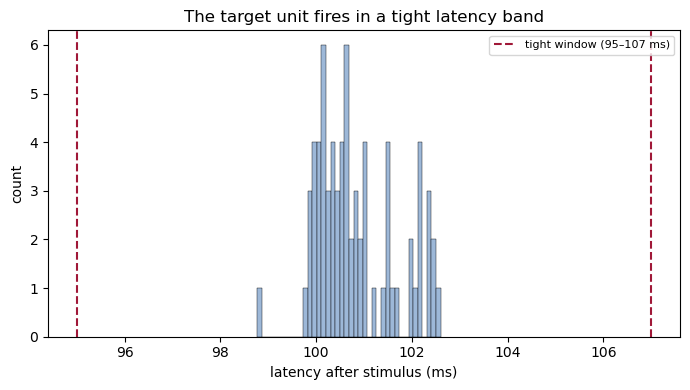

In [81]:
#Latency of each ground truth spike relative to its preceding stimulus
lat = [] 
for st in gt_in_win:
    prev = ttls[ttls <= st]
    if len(prev):
        lat.append((st - prev[-1]) * 1000)  
lat = np.array(lat)
print(f"n spikes: {len(lat)}")
print(f"median: {np.median(lat):.1f} ms")
print(f"2nd-98th pct: {np.percentile(lat,2):.1f} - {np.percentile(lat,98):.1f} ms")
print(f"min-max: {lat.min():.1f} - {lat.max():.1f} ms")

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(lat, bins=40, color="#9db8d8", edgecolor="k", linewidth=0.3)
ax.axvline(95,  color="#a01838", ls="--", lw=1.5, label="tight window (95–107 ms)")
ax.axvline(107, color="#a01838", ls="--", lw=1.5)
ax.set_xlabel("latency after stimulus (ms)")
ax.set_ylabel("count")
ax.set_title("The target unit fires in a tight latency band")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("figures/latency_cluster.png", dpi=150)
plt.show()


## Figure 6.
Post-stimulus latency of the 71 ground truth spikes in the 300s CH19 window. Latency is measured as the time between each spike and its preceding electrical stimulus. Within this window, the latencies form a tight cluster between 98.8 and 102.6 ms (a ~4 ms band, median 100.6ms), whereas across the full recording they range more widely (~94-152 ms), explaining activity-dependent conduction slowing in C-fibres (Serra et al 1999). The tight window clustering justifies restricting detection to a narrow latency window (95-107 ms, dashed lines), because the target unit fires reliably in this 4ms band; the window retains the target spikes while rejecting other fibres and noise firing at other latencies, which is why the tight window sharply improves precision (Figure1). 

**reference for the thesis** **needs to be changed to my own words**: Three types of C unit were distinguished by their responses to repetitive stimulation: type 1 units slowed progressively during the 3 min trains; slowing of type 2 units reached a plateau within 1 min; while type 3 units hardly slowed at all. Data from normal and diabetic subjects did not differ and were pooled. After 3 min at 2 Hz, the percentage increases in latency were for type 1, 28.3 +/- 9.7 (n = 63 units, mean +/- s.d.); for type 2, 5.2 +/- 1.6 (n = 14); and for type 3, 0.8 +/- 0.5 (n = 5), with no overlap." A later paper by Baker & Waxman (2012) explains the underlying mechanism, describing this phenomenon as an "increase in impulse latency that can build up over minutes, elicited even in response to low firing rates" 

In [91]:
raw_snr, raw_con, raw_mad = 2.14, 0.519, 4.94
rows = [
    ("raw",      2.14, 0.519, 4.94),
    ("wavelet",  2.00, 0.606, 3.20),
    ("conv AE",  6.51, 0.654, 1.35),
    ("N2V",      2.17, 0.523, 4.68),
    ("dense AE", 4.83, 0.683, 0.57),
]
tbl = pd.DataFrame([{
    "Denoiser": n,
    "SNR": f"{s:.2f}",
    "Fold-change (SNR)": f"{s/raw_snr:.2f}×",
    "Consistency": f"{c:.3f}",
    "Fold-change (Consistency)": f"{c/raw_con:.2f}×",
    "MAD": f"{m:.2f}",
    "Fold-change (MAD)": f"{m/raw_mad:.2f}×",
} for n, s, c, m in rows])
tbl.to_csv("figures/denoiser_quality.csv", index=False)
tbl

,Denoiser,SNR,Fold-change (SNR),Consistency,Fold-change (Consistency),MAD,Fold-change (MAD)
0,raw,2.14,1.00×,0.519,1.00×,4.94,1.00×
1,wavelet,2.00,0.93×,0.606,1.17×,3.20,0.65×
2,conv AE,6.51,3.04×,0.654,1.26×,1.35,0.27×
3,N2V,2.17,1.01×,0.523,1.01×,4.68,0.95×
4,dense AE,4.83,2.26×,0.683,1.32×,0.57,0.12×


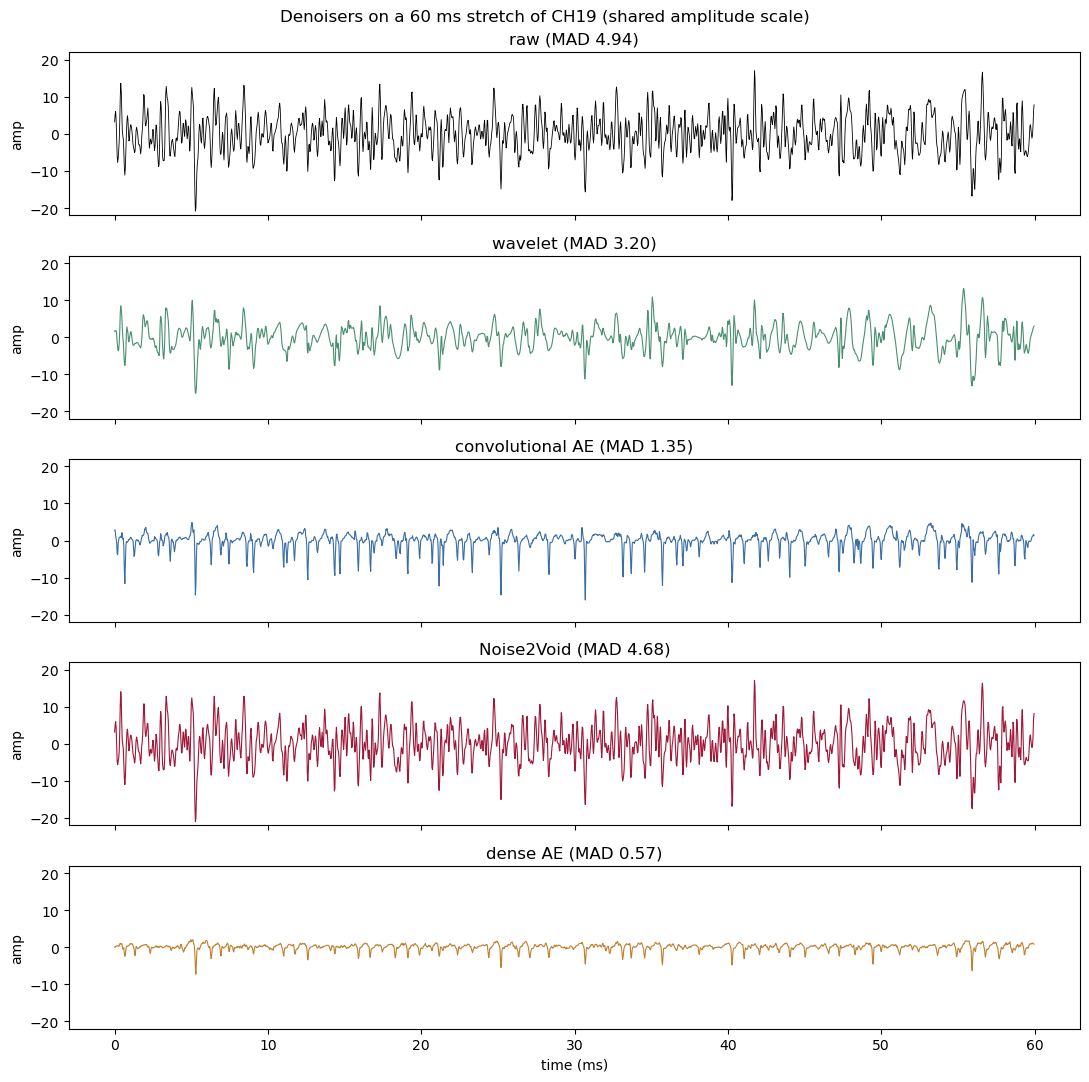

In [93]:
i = int((gt_in_win[10] - t_start) * sample_rate)   # a clear spike
i0 = i - 900
w = slice(i0, i0 + 1800)          # 60 ms stretch
tt = np.arange(1800) / sample_rate * 1000

fig, ax = plt.subplots(5, 1, figsize=(11, 11), sharex=True, sharey=True)
ax[0].plot(tt, ch19[w],      'k',       lw=0.6); ax[0].set_title("raw (MAD 4.94)")
ax[1].plot(tt, ch19_wav[w],  '#4a9070', lw=0.8); ax[1].set_title("wavelet (MAD 3.20)")
ax[2].plot(tt, ch19_conv[w], '#3a6ea5', lw=0.8); ax[2].set_title("convolutional AE (MAD 1.35)")
ax[3].plot(tt, ch19_n2v[w],  '#a01838', lw=0.8); ax[3].set_title("Noise2Void (MAD 4.68)")
ax[4].plot(tt, ch19_ae[w],   '#c08030', lw=0.8); ax[4].set_title("dense AE (MAD 0.57)")
for a in ax:
    a.set_ylabel("amp")
ax[0].set_ylim(-22, 22)           
ax[4].set_xlabel("time (ms)")
plt.suptitle("Denoisers on a 60 ms stretch of CH19 (shared amplitude scale)")
plt.tight_layout()
plt.savefig("figures/denoisers_5panel.png", dpi=150)
plt.show()

## Table and Figure 7. Denoiser comparison 